## Tiro paralabólico



En el tiro parabólico (sin rozamiento), la posición $(x, y)$ de una partícula de masa $m$ obedece
$$
\ddot{x} = 0, \qquad \ddot{y} = -g,
$$
donde $g$ es la aceleración de la gravedad.

Podemos escribir estas ecuaciones de segundo orden como un sistema de primer orden introduciendo las velocidades $v_x = \dot{x}$ y $v_y = \dot{y}$:
$$
\begin{cases}
\dot{x} = v_x, \\
\dot{y} = v_y, \\
\dot{v}_x = 0, \\
\dot{v}_y = -g.
\end{cases}
$$


El método de Euler aproxima las derivadas por diferencias finitas en pasos de tiempo (\Delta t):
$$\begin{aligned}
x_{n+1} &= x_n + v_{x,n} \Delta t,\\
y_{n+1} &= y_n + v_{y,n}\Delta t,\\
v_{x,n+1} &= v_{x,n} + 0 \cdot \Delta t = v_{x,n},\\
v_{y,n+1} &= v_{y,n} - g \Delta t.
\end{aligned}
$$


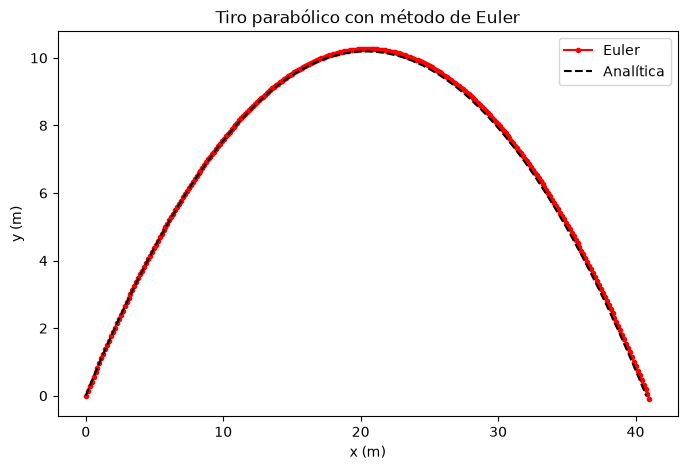

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos
g = 9.81          # gravedad (m/s^2)
v0 = 20.0         # velocidad inicial (m/s)
theta = 45.0      # ángulo inicial (grados)
dt = 0.01         # paso temporal (s)


theta_rad = np.radians(theta)

# Componentes iniciales de la velocidad
vx0 = v0 * np.cos(theta_rad)
vy0 = v0 * np.sin(theta_rad)

x0=0
y0=0

# Condiciones iniciales
x, y = [x0], [y0] #Creación de dos listas de momento con un solo elemento
vx, vy = [vx0], [vy0]


while y[-1] >= 0:  #El [-1] nos indica que es el último elemento del vector el que se coge
    
    vx_new = vx[-1]                
    vy_new = vy[-1] - g * dt        
    
    x_new = x[-1] + vx[-1] * dt
    y_new = y[-1] + vy[-1] * dt

    vx.append(vx_new)
    vy.append(vy_new)
    x.append(x_new) 
    y.append(y_new)


x = np.array(x) 
y = np.array(y)


t_f = (v0 * np.sin(theta_rad) + np.sqrt((v0 * np.sin(theta_rad))**2 + 2 * g * y0)) / g
t_analitico = np.linspace(0, t_f, 200)
x_analitico = x0+v0 * np.cos(theta_rad) * t_analitico
y_analitico = y0+v0 * np.sin(theta_rad) * t_analitico - 0.5 * g * t_analitico**2


plt.figure(figsize=(8,5))
plt.plot(x, y, 'r.-', label='Euler')
plt.plot(x_analitico, y_analitico, 'k--', label='Analítica')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Tiro parabólico con método de Euler')
plt.legend()

plt.show()


# Oscilador armónico

Vamos a aplicar el **método de Euler** al oscilador armónico simple
$$
\ddot{x} = -\omega^2 x
$$
donde $\omega$ es la frecuencia angular.


Definimos las variables:
$$
v = \dot{x}, \quad \Rightarrow
\begin{cases}
\dot{x} = v \\
\dot{v} = -\omega^2 x
\end{cases}
$$
De esta forma, el problema se convierte en un sistema de ecuaciones de primer orden.


### Método de Euler

El método de Euler aproxima las derivadas con incrementos finitos:
$$
\begin{aligned}
x_{n+1} &= x_n + v_n  \Delta t \\
v_{n+1} &= v_n - \omega^2 x_n  \Delta t
\end{aligned}
$$

In [2]:
def euler(x0, v0, omega, dt, N):
    x = np.zeros(N+1)
    v = np.zeros(N+1)
    x[0], v[0] = x0, v0
    for n in range(N):
        x[n+1] = x[n] + dt * v[n]
        v[n+1] = v[n] - dt * omega**2 * x[n]
    return np.arange(N+1)*dt,x, v

In [3]:
# Parámetros
ω = 1.0
dt = 0.05
N = 1500

x0, v0 = 1.0, 0.0

# Integraciones
t=np.arange(N+1)*dt
x_exact = x0 * np.cos(ω * t)


t_e,x_e, v_e = euler(x0, v0, ω, dt, N) #Se lo pone en el orden de salida de las variables



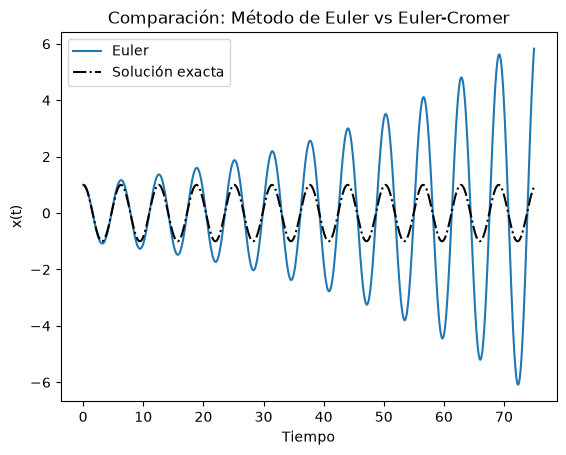

In [4]:
plt.plot(t_e, x_e, label='Euler')

plt.plot(t, x_exact, 'k-.', label='Solución exacta')

plt.xlabel('Tiempo')
plt.ylabel('x(t)')
plt.title('Comparación: Método de Euler vs Euler-Cromer')
plt.legend()

plt.show()



### Método de Euler-Cromer

El método de Euler-Cromer modifica ligeramente la actualización:
$$
\begin{aligned}
v_{n+1} &= v_n - \omega^2 x_n  \Delta t \\
x_{n+1} &= x_n + v_{n+1} \Delta t
\end{aligned}
$$
Es decir, primero se actualiza la velocidad y luego se usa el nuevo valor $v_{n+1}$ para actualizar la posición.
Esta simple corrección mejora la **conservación de la energía** y la **estabilidad** numérica.



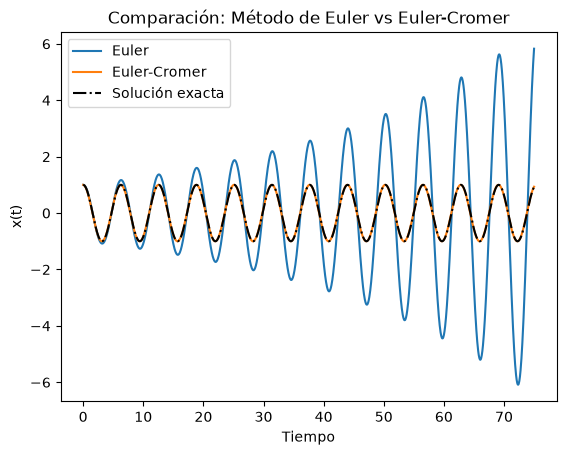

In [5]:
#Se usa cuando hay fuerzas restauradoras, ya que la fuerza influye en la vel. y esto 
#afecta a la siguiente posición que se ve mucho más moderada
#sobre todo para sistemas oscilatorios
def euler_cromer(x0, v0, omega, dt, N):
    x = np.zeros(N+1)
    v = np.zeros(N+1)
    x[0], v[0] = x0, v0
    for n in range(N):
        v[n+1] = v[n] - dt * omega**2 * x[n]
        x[n+1] = x[n] + dt * v[n+1]
    return  np.arange(N+1)*dt,x, v

t_ec,x_ec, v_ec = euler_cromer(x0, v0, ω, dt, N)


plt.plot(t_e, x_e, label='Euler')
plt.plot(t_ec, x_ec,'-', label='Euler-Cromer')
plt.plot(t, x_exact, 'k-.', label='Solución exacta')

plt.xlabel('Tiempo')
plt.ylabel('x(t)')
plt.title('Comparación: Método de Euler vs Euler-Cromer')
plt.legend()

plt.show()

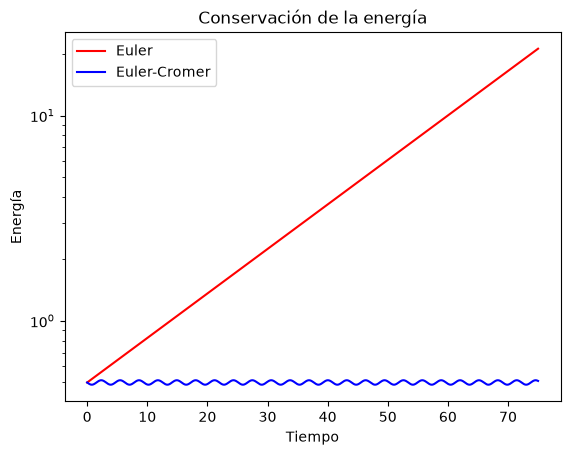

In [6]:

E_euler = 0.5 * (v_e**2 + (ω*x_e)**2)
E_cromer = 0.5 * (v_ec**2 + (ω*x_ec)**2)

plt.figure()
plt.plot(t, E_euler, 'r-', label='Euler')
plt.plot(t, E_cromer, 'b-', label='Euler-Cromer')
plt.xlabel('Tiempo')
plt.ylabel('Energía')
plt.title('Conservación de la energía')
plt.legend()
plt.yscale('log')
plt.show()


### método de Runge–Kutta de orden 2 (RK2)
$$
\begin{aligned}
k_{1x} &= v_n,\\
k_{1v} &= -\omega^2 x_n,\\
k_{2x} &= v_n + \tfrac{\Delta t}{2}k_{1v},\\
k_{2v} &= -\omega^2 \left(x_n + \tfrac{\Delta t}{2}k_{1x}\right),\\
x_{n+1} &= x_n + \Delta t k_{2x},\\
v_{n+1} &= v_n + \Delta t k_{2v}.
\end{aligned}
$$

In [7]:
def rk2(x0, v0, omega, dt, N):
    x = np.zeros(N+1)
    v = np.zeros(N+1)
    x[0], v[0] = x0, v0

    for n in range(N):
        # Derivadas en el punto inicial
        k1x = v[n]
        k1v = -omega**2 * x[n]

        # Evaluación intermedia (punto medio)
        k2x = v[n] + 0.5*dt*k1v
        k2v = -omega**2 * (x[n] + 0.5*dt*k1x)

        # Actualización
        x[n+1] = x[n] + dt * k2x
        v[n+1] = v[n] + dt * k2v

    t = np.arange(N+1) * dt
    return t, x, v



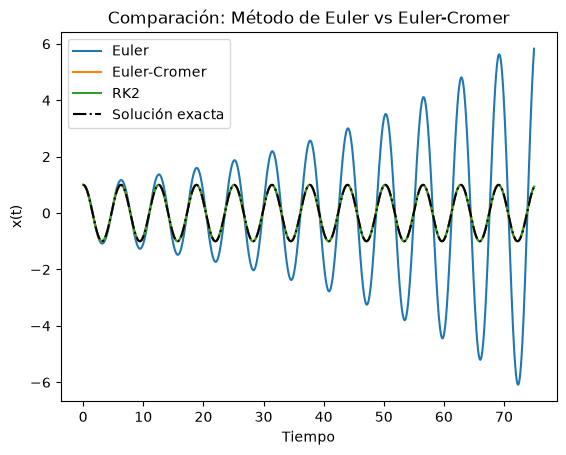

In [8]:
t_rk2,x_rk2, v_rk2 = rk2(x0, v0, ω, dt, N)


plt.plot(t_e, x_e, label='Euler')
plt.plot(t_ec, x_ec,'-', label='Euler-Cromer')
plt.plot(t_rk2, x_rk2,'-', label='RK2')
plt.plot(t, x_exact, 'k-.', label='Solución exacta')

plt.xlabel('Tiempo')
plt.ylabel('x(t)')
plt.title('Comparación: Método de Euler vs Euler-Cromer')
plt.legend()

plt.show()

### Esquema de **Runge–Kutta de orden 4 (RK4)**

$$
\begin{aligned}
k_{1x} &= v_n, \\
k_{1v} &= -\omega^2 x_n, \\[4pt]
k_{2x} &= v_n + \tfrac{\Delta t}{2} k_{1v}, \\
k_{2v} &= -\omega^2 \left(x_n + \tfrac{\Delta t}{2} k_{1x}\right), \\[4pt]
k_{3x} &= v_n + \tfrac{\Delta t}{2} k_{2v}, \\
k_{3v} &= -\omega^2 \left(x_n + \tfrac{\Delta t}{2} k_{2x}\right), \\[4pt]
k_{4x} &= v_n + \Delta t, k_{3v}, \\
k_{4v} &= -\omega^2 \left(x_n + \Delta t, k_{3x}\right), \\[6pt]
x_{n+1} &= x_n + \tfrac{\Delta t}{6}(k_{1x} + 2k_{2x} + 2k_{3x} + k_{4x}), \\
v_{n+1} &= v_n + \tfrac{\Delta t}{6}(k_{1v} + 2k_{2v} + 2k_{3v} + k_{4v}).
\end{aligned}
$$

In [9]:
def rk4(x0, v0, omega, dt, N):
    x = np.zeros(N+1)
    v = np.zeros(N+1)
    x[0], v[0] = x0, v0

    for n in range(N):
        k1x = v[n]
        k1v = -omega**2 * x[n]

        k2x = v[n] + 0.5*dt*k1v
        k2v = -omega**2 * (x[n] + 0.5*dt*k1x)

        k3x = v[n] + 0.5*dt*k2v
        k3v = -omega**2 * (x[n] + 0.5*dt*k2x)

        k4x = v[n] + dt*k3v
        k4v = -omega**2 * (x[n] + dt*k3x)

        x[n+1] = x[n] + (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
        v[n+1] = v[n] + (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)

    t = np.arange(N+1)*dt
    return t, x, v



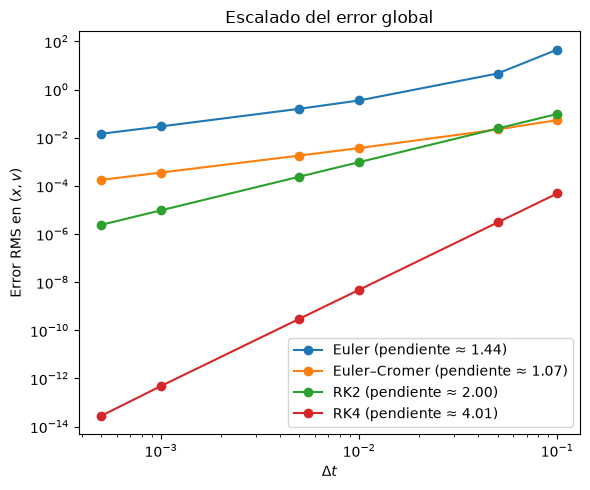

In [11]:

def exact(t):
    x = x0*np.cos(ω*t) + (v0/ω)*np.sin(ω*t)
    v = -x0*ω*np.sin(ω*t) + v0*np.cos(ω*t)
    return x, v


def rms_error(t, x, v):
    xe, ve = exact(t)
    return np.sqrt(np.mean((x-xe)**2 + (v-ve)**2))

methods = {
    "Euler": euler,
    "Euler–Cromer": euler_cromer,
    "RK2": rk2,
    "RK4": rk4,
}

T=100 #Tiempo máximo

dts = np.array([0.0005,0.001,0.005,0.01,0.05,0.1])

orders = {}
plt.figure(figsize=(6,5))
for name, solver in methods.items():
    errs = []
    for dt in dts:
        #print(name,dt)
        N = int(np.floor(T/dt))
        t, x, v = solver(x0, v0, ω, dt, N)
        errs.append(rms_error(t, x, v))
    errs = np.array(errs)
    m, b = np.polyfit(np.log(dts), np.log(errs), 1)  # pendiente ≈ orden
    orders[name] = m
    plt.loglog(dts, errs, 'o-', label=f"{name} (pendiente ≈ {m:.2f})")

plt.xlabel(r"$\Delta t$")
plt.ylabel("Error RMS en $(x,v)$")
plt.title("Escalado del error global")

plt.legend()
plt.tight_layout()
plt.show()



---

**Ejercicio:**
Considera el movimiento de un péndulo amortiguado descrito por la ecuación diferencial

$$
\ddot{\theta} = -\frac{g}{L}\sin\theta - \beta\dot{\theta}.
$$

Integra numéricamente estas ecuaciones de movimiento empleando los métodos de **Euler**, **Runge–Kutta de orden 2 (RK2)** y **Runge–Kutta de orden 4 (RK4)**.

Representa gráficamente:

* la evolución temporal del ángulo, $\theta(t)$,
* y el retrato de fase, $\omega(\theta)$, con $\omega = \dot{\theta}$.

Utiliza unidades reducidas con $g/L = 1$ y un coeficiente de amortiguamiento $\beta = 0.5$.

Compara los resultados obtenidos con cada método y comenta las diferencias observadas en precisión y estabilidad numérica.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def f(theta, omega, beta=0.2):
    return omega, -np.sin(theta) - beta*omega

def euler(theta0, omega0, dt, T, beta=0.2):
    N = int(np.floor(T/dt))
    t  = np.arange(N+1)*dt
    th = np.empty(N+1); om = np.empty(N+1)
    th[0], om[0] = theta0, omega0
    for n in range(N):
        k1_th, k1_om = f(th[n], om[n], beta)
        th[n+1] = th[n] + dt*k1_th
        om[n+1] = om[n] + dt*k1_om
    return t, th, om

def rk2(theta0, omega0, dt, T, beta=0.2):
    N = int(np.floor(T/dt))
    t  = np.arange(N+1)*dt
    th = np.empty(N+1); om = np.empty(N+1)
    th[0], om[0] = theta0, omega0
    for n in range(N):
        k1_th, k1_om = f(th[n], om[n], beta)
        th_m = th[n] + 0.5*dt*k1_th
        om_m = om[n] + 0.5*dt*k1_om
        k2_th, k2_om = f(th_m, om_m, beta)
        th[n+1] = th[n] + dt*k2_th
        om[n+1] = om[n] + dt*k2_om
    return t, th, om

def rk4(theta0, omega0, dt, T, beta=0.2):
    N = int(np.floor(T/dt))
    t  = np.arange(N+1)*dt
    th = np.empty(N+1); om = np.empty(N+1)
    th[0], om[0] = theta0, omega0
    for n in range(N):
        k1_th, k1_om = f(th[n], om[n], beta)

        th2 = th[n] + 0.5*dt*k1_th
        om2 = om[n] + 0.5*dt*k1_om
        k2_th, k2_om = f(th2, om2, beta)

        th3 = th[n] + 0.5*dt*k2_th
        om3 = om[n] + 0.5*dt*k2_om
        k3_th, k3_om = f(th3, om3, beta)

        th4 = th[n] + dt*k3_th
        om4 = om[n] + dt*k3_om
        k4_th, k4_om = f(th4, om4, beta)

        th[n+1] = th[n] + (dt/6.0)*(k1_th + 2*k2_th + 2*k3_th + k4_th)
        om[n+1] = om[n] + (dt/6.0)*(k1_om + 2*k2_om + 2*k3_om + k4_om)
    return t, th, om


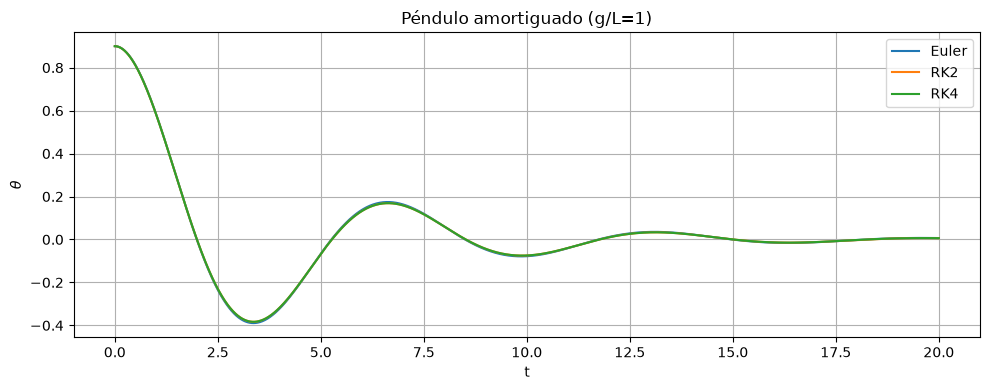

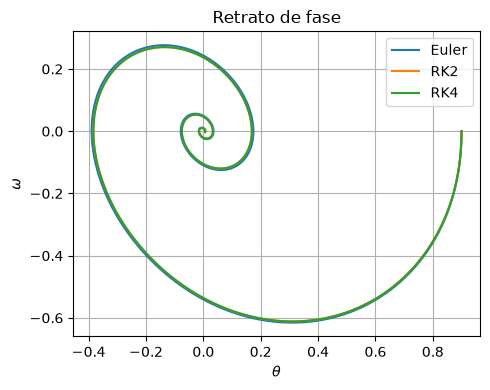

In [13]:
theta0, omega0 = 0.9, 0.0
beta = 0.5
dt, T = 0.01, 20.0

t1, th_eu, om_eu = euler(theta0, omega0, dt, T, beta)
t2, th_r2, om_r2 = rk2(theta0, omega0, dt, T, beta)
t3, th_r4, om_r4 = rk4(theta0, omega0, dt, T, beta)

plt.figure(figsize=(10,4))
plt.plot(t1, th_eu,  label="Euler")
plt.plot(t2, th_r2,  label="RK2")
plt.plot(t3, th_r4,  label="RK4")
plt.xlabel("t"); plt.ylabel(r"$\theta$")
plt.title("Péndulo amortiguado (g/L=1)")
plt.grid(True); plt.legend(); plt.tight_layout()

plt.figure(figsize=(5,4))
plt.plot(th_eu, om_eu,  label="Euler")
plt.plot(th_r2, om_r2,  label="RK2")
plt.plot(th_r4, om_r4,  label="RK4")
plt.xlabel(r"$\theta$"); plt.ylabel(r"$\omega$")
plt.title("Retrato de fase")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


# Prueba ec dif péndulo

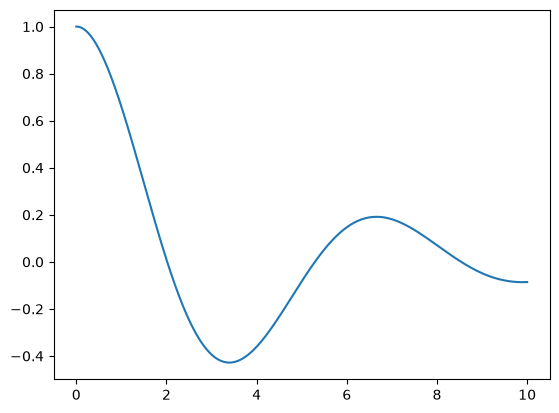

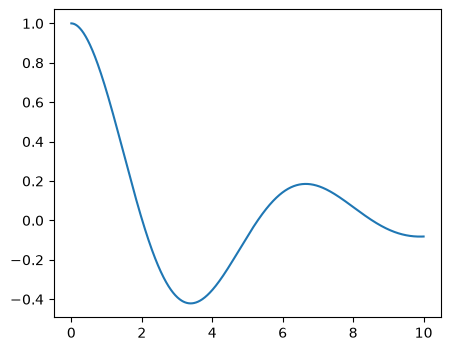

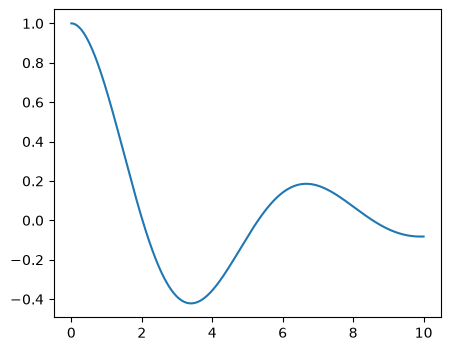

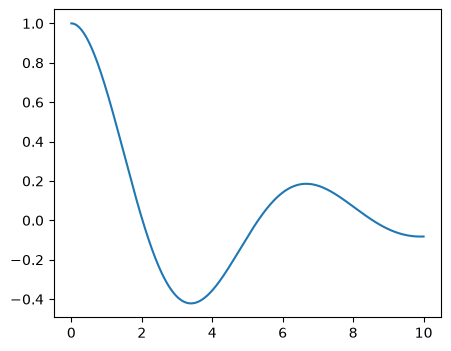

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def f(theta, omega, beta=0.5):
    return np.array([omega, -np.sin(theta)-beta*omega])

def euler (theta0, omega0, N, dt,beta=0.5):
    t= np.arange(N+1)*dt
    th = [theta0]
    om = [omega0]
    for n in range(N):
        k1_th, k1_om =f(th[n] ,om[n] ,beta) 
        x= th[-1]+ om[-1]*dt
        w= om[-1] + k1_om*dt
        th.append(x)
        om.append(w)
    return th, om, t

th, om, t = euler(1, 0, 1_000, 0.01)
th= np.array(th)
om= np.array(om)
t= np.array(t)
plt.figure()
plt.plot(t,th)
plt.show()

def euler_cromer(theta0, omega0, N, dt, beta= 0.5):
    t= np.arange(N+1)*dt
    om = np.empty(N+1)
    th = np.empty(N+1)
    om[0], th[0] = omega0, theta0
    for n in range (N):
        k1_f, k2_f = f(th[n], om[n], beta)
        om[n+1] = om[n]+ k2_f*dt 
        th[n+1] = th[n] + om[n+1]*dt
    return th, om, t
th1, om1, t1 = euler_cromer(1,0,1_000,0.01)

plt.figure(figsize=(5,4))
plt.plot(t1, th1)
plt.show()

def rk2(theta0, omega0, N, dt, beta=0.5):
    #creación de ks
    t = np.arange(N+1)*dt
    th = np.empty(N+1)
    om = np.empty(N+1)
    th[0], om[0] = theta0, omega0
    for n in range(N):
        k1x, k1w = f(th[n], om[n], beta)

        k2x, k2w = f(th[n]+dt/2*k1x, om[n]+dt/2*k1w, beta)

        th[n+1]= th[n] + dt*k2x
        om[n+1]= om[n] + dt*k2w
    return th, om, t
th2, om2, t2= rk2(1,0,1_000,0.01)
plt.figure(figsize=(5,4))
plt.plot(t2, th2)
plt.show()

def rk4(theta0, omega0, N, dt, beta=0.5):
    #creación de ks
    t = np.arange(N+1)*dt
    th = np.empty(N+1)
    om = np.empty(N+1)
    th[0], om[0] = theta0, omega0
    for n in range(N):
        k1x, k1w = f(th[n], om[n], beta)
        k2x, k2w = f(th[n] + dt/2*k1x, om[n] + dt/2*k1w, beta)
        k3x, k3w = f(th[n] + dt/2*k2x, om[n] + dt/2*k2w, beta)
        k4x, k4w = f(th[n] + dt*k3x, om[n] + dt*k3w, beta)

        th[n+1] = th[n] + (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
        om[n+1] = om[n] + (dt/6)*(k1w + 2*k2w + 2*k3w + k4w)

    return th, om, t
th3, om3, t3 = rk4(1,0,1_000,0.01)
plt.figure(figsize=(5,4))
plt.plot(t3,th3)
plt.show()


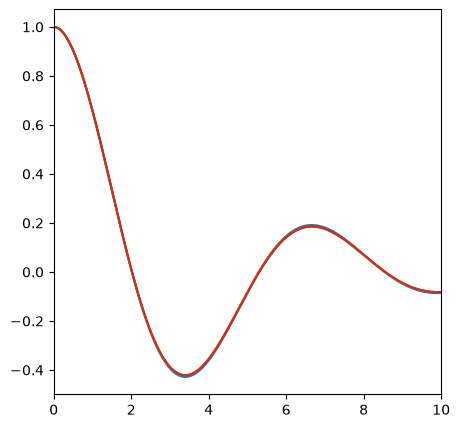

In [15]:
plt.figure(figsize=(5,5))
plt.plot(t, th)
plt.plot(t1, th1)
plt.plot(t2, th2)
plt.plot(t3, th3)
plt.xlim(0,10)
plt.show()

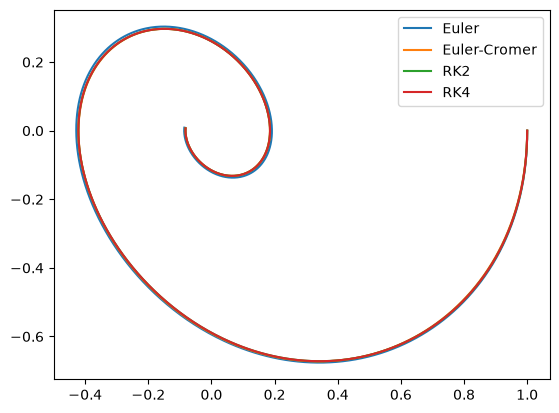

In [16]:

plt.figure()
plt.plot(th, om, label= "Euler")
plt.plot(th1, om1, label= "Euler-Cromer")
plt.plot(th2, om2, label= "RK2")
plt.plot(th3, om3, label= "RK4")
plt.legend()
plt.show()